In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("car data.csv")

# Feature Engineering
df["Car_Age"] = 2026 - df["Year"]

# Drop unnecessary column
df = df.drop("Year", axis=1)

print(df.head())

  Car_Name  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0     ritz           3.35           5.59       27000    Petrol       Dealer   
1      sx4           4.75           9.54       43000    Diesel       Dealer   
2     ciaz           7.25           9.85        6900    Petrol       Dealer   
3  wagon r           2.85           4.15        5200    Petrol       Dealer   
4    swift           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       12  
1       Manual      0       13  
2       Manual      0        9  
3       Manual      0       15  
4       Manual      0       12  


In [2]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [3]:
numeric_features = [
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

categorical_features = [
    "Car_Name",
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [7]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        )
    )
])

decision_tree.fit(X_train, y_train)

tree_pred = decision_tree.predict(X_test)

In [8]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42
        )
    )
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

gradient_boosting.fit(X_train, y_train)

gb_pred = gradient_boosting.predict(X_test)

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

models = {
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

results = []

for name, prediction in models.items():

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  1.032383  2.497688  1.580408  0.891573
1      Decision Tree  0.663593  1.193700  1.092566  0.948180
2      Random Forest  0.626248  0.900512  0.948953  0.960908
3  Gradient Boosting  0.602163  1.012732  1.006346  0.956036


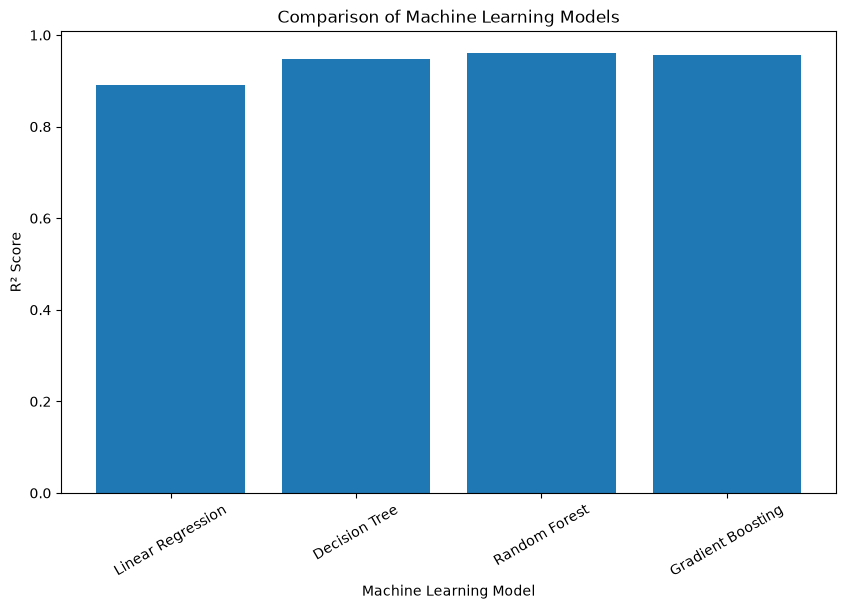

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Machine Learning Model")

plt.ylabel("R² Score")

plt.xticks(rotation=30)

plt.show()

In [12]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
MAE              0.626248
MSE              0.900512
RMSE             0.948953
R2 Score         0.960908
Name: 2, dtype: object


In [13]:
new_car = pd.DataFrame({
    "Car_Name": ["ciaz"],
    "Present_Price": [10.0],
    "Driven_kms": [30000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0],
    "Car_Age": [4]
})

In [14]:
predicted_price = random_forest.predict(new_car)

print(
    "Predicted Car Price:",
    predicted_price[0]
)

Predicted Car Price: 7.82
